## Tracer Study


# 2_Exploratory Data Analysis - FINAL
## Structure:
1. ...

### Import Data and Required Packages

In [534]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

plt.style.use("default")

In [535]:
if False:

    sns.set_theme(
        style="whitegrid",
        context="talk",
        palette="Set2"
    )

### Loading Clean Data Set

In [536]:
# ---------------------------------
# Load Clean Dataset
# ---------------------------------

df = pd.read_csv("data/Tracer Data - Clean.csv")

print()

print(df.shape)

print()   

display(df.head())


(157, 13)



,employment_outcome,program,study_hours,internship,mandatory_internship_num,working_student,skills_index,learning_environment_index,search_timing,num_applications,num_interviews,sex,age
0,Fast Employment,BEED,3,1,2,0,4.166667,4.666667,3,2,1,1,24
1,Delayed/Non-Employment,BEED,1,1,1,1,5.000000,5.000000,1,2,2,0,24
2,Fast Employment,BEED,1,1,1,0,4.833333,5.000000,1,2,1,0,23
3,Fast Employment,BEED,3,1,2,1,5.000000,5.000000,1,1,1,1,23
4,Fast Employment,BEED,1,1,2,0,5.000000,5.000000,4,2,1,1,24


### 1. Dataset Overview

In [537]:
print("="*60)
print("\033[1mDATASET OVERVIEW\033[0m")
print("="*60)

print("\033[1m\nShape\033[0m")
print(df.shape)

print("\033[1m\nData Types\033[0m")
display(df.dtypes)

print("\033[1m\nMissing Values\033[0m")
display(df.isnull().sum())

print()
print("\033[1m\nSummary Statistics\033[0m")
print()
display(df.describe(include="all"))

DATASET OVERVIEW

Shape
(157, 13)

Data Types


employment_outcome                str
program                           str
study_hours                     int64
internship                      int64
mandatory_internship_num        int64
working_student                 int64
skills_index                  float64
learning_environment_index    float64
search_timing                   int64
num_applications                int64
num_interviews                  int64
sex                             int64
age                             int64
dtype: object


Missing Values


employment_outcome            0
program                       0
study_hours                   0
internship                    0
mandatory_internship_num      0
working_student               0
skills_index                  0
learning_environment_index    0
search_timing                 0
num_applications              0
num_interviews                0
sex                           0
age                           0
dtype: int64



Summary Statistics



,employment_outcome,program,study_hours,internship,mandatory_internship_num,working_student,skills_index,learning_environment_index,search_timing,num_applications,num_interviews,sex,age
count,157,157,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000
unique,2,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Fast Employment,BSEd English,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,128,59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2.159236,0.980892,1.847134,0.356688,4.553079,4.532909,2.038217,2.191083,1.961783,0.783439,24.382166
std,NaN,NaN,1.288557,0.137344,0.760951,0.480554,0.559507,0.533573,1.786292,1.177425,1.142901,0.413219,2.456115
min,NaN,NaN,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,16.000000
25%,NaN,NaN,1.000000,1.000000,1.000000,0.000000,4.000000,4.333333,1.000000,1.000000,1.000000,1.000000,23.000000
50%,NaN,NaN,2.000000,1.000000,2.000000,0.000000,4.833333,4.666667,1.000000,2.000000,2.000000,1.000000,24.000000
75%,NaN,NaN,3.000000,1.000000,2.000000,1.000000,5.000000,5.000000,2.000000,2.000000,2.000000,1.000000,25.000000


### Label Dictionaries

In [538]:
# ---------------------------------
# Labels for Encoded Variables
# ---------------------------------

label_maps = {

    "study_hours": {
        1: "≤10 hrs",
        2: "11–19 hrs",
        3: "20–29 hrs",
        4: "30–39 hrs",
        5: "≥40 hrs"
    },

    "mandatory_internship_num": {
        0: "None",
        1: "One",
        2: "Two",
        3: "Three",
        4: "Four+"
    },

    "search_timing": {
        1: "Before Graduation",
        2: "Right After Graduation",
        3: "1–<3 Months",
        4: "3–<6 Months",
        5: "≥6 Months",
        6: "Never Applied",
        7: "N/A"
    },

    "num_applications": {
        0: "None",
        1: "1",
        2: "2–4",
        3: "5–9",
        4: "10+",
        5: "N/A"
    },

    "num_interviews": {
        0: "None",
        1: "1",
        2: "2–4",
        3: "5–9",
        4: "10+",
        5: "N/A"
    },

    "internship": {
        0: "No",
        1: "Yes"
    },

    "working_student": {
        0: "No",
        1: "Yes"
    },

    "sex": {
        0: "Male",
        1: "Female"
    }

}

### 1. Univariate Analysis

In [539]:
# ==========================================================
# Univariate Summary of Key Study Variables
# ==========================================================

# ---------------------------------
# Numerical Variables
# ---------------------------------

numeric_cols = [
    "age",
    "skills_index",
    "learning_environment_index"
]

print("=" * 70)
print("UNIVARIATE SUMMARY: NUMERICAL VARIABLES")
print("=" * 70)

numeric_summary = (
    df[numeric_cols]
    .describe()
    .T[
        ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
    ]
    .round(2)
)

display(numeric_summary)


# ---------------------------------
# Categorical Variables
# ---------------------------------

categorical_cols = {
    "program": "Program",
    "sex": "Sex",
    "internship": "Internship Experience",
    "working_student": "Working Student",
    "study_hours": "Study Hours",
    "mandatory_internship_num": "Mandatory Internships",
    "search_timing": "Job Search Timing",
    "num_applications": "Number of Applications",
    "num_interviews": "Number of Interviews",
    "employment_outcome": "Employment Outcome"
}

print("\n" + "=" * 70)
print("UNIVARIATE SUMMARY: CATEGORICAL VARIABLES")
print("=" * 70)

for col, title in categorical_cols.items():

    print(f"\n{title}")
    print("-" * len(title))

    summary = pd.DataFrame({
        "Frequency": df[col].value_counts(dropna=False),
        "Percentage (%)": (
            df[col]
            .value_counts(normalize=True, dropna=False)
            .mul(100)
            .round(2)
        )
    })

    # Convert encoded values to labels when available
    if col in label_maps:
        summary.index = [
            label_maps[col].get(i, i)
            for i in summary.index
        ]

    display(summary)

UNIVARIATE SUMMARY: NUMERICAL VARIABLES


,count,mean,std,min,25%,50%,75%,max
age,157.0,24.38,2.46,16.0,23.00,24.00,25.0,38.0
skills_index,157.0,4.55,0.56,2.0,4.00,4.83,5.0,5.0
learning_environment_index,157.0,4.53,0.53,2.0,4.33,4.67,5.0,5.0



UNIVARIATE SUMMARY: CATEGORICAL VARIABLES

Program
-------


,Frequency,Percentage (%)
program,,
BSEd English,59,37.58
BEED,46,29.30
BSEd Science,28,17.83
BSEd Math,24,15.29



Sex
---


...

,Frequency,Percentage (%)
2–4,76,48.41
1,40,25.48
5–9,19,12.10
N/A,15,9.55
10+,5,3.18
None,2,1.27



Number of Interviews
--------------------


,Frequency,Percentage (%)
2–4,85,54.14
1,48,30.57
N/A,15,9.55
5–9,5,3.18
None,4,2.55



Employment Outcome
------------------


,Frequency,Percentage (%)
employment_outcome,,
Fast Employment,128,81.53
Delayed/Non-Employment,29,18.47


In [540]:
# ==========================================================
# Table. Univariate Summary of the Target and Predictor Variables
# ==========================================================

# ---------------------------------
# Variable Labels
# ---------------------------------

variable_labels = {

    "employment_outcome": "Employment Outcome",

    "age": "Age",
    "internship": "Internship Experience",
    "learning_environment_index": "Learning Environment Index",
    "mandatory_internship_num": "Number of Mandatory Internships",
    "num_applications": "Number of Applications",
    "num_interviews": "Number of Interviews",
    "program": "Program",
    "search_timing": "Job Search Timing",
    "sex": "Sex",
    "skills_index": "Skills Index",
    "study_hours": "Study Hours",
    "working_student": "Working Student"

}

# ---------------------------------
# Variable Order
# ---------------------------------

target = ["employment_outcome"]

predictors = sorted([
    "age",
    "internship",
    "learning_environment_index",
    "mandatory_internship_num",
    "num_applications",
    "num_interviews",
    "program",
    "search_timing",
    "sex",
    "skills_index",
    "study_hours",
    "working_student"
])

variables = target + predictors

# ---------------------------------
# Numerical Variables
# ---------------------------------

numeric_variables = {
    "age",
    "skills_index",
    "learning_environment_index"
}

# ---------------------------------
# Build Summary Table
# ---------------------------------

rows = []

for col in variables:

    # ---------------------------------
    # Numerical Variables
    # ---------------------------------

    if col in numeric_variables:

        rows.append({
            "Variable": variable_labels[col],
            "Category": "Mean ± SD",
            "Statistics":
                f"{df[col].mean():.2f} ± {df[col].std():.2f}"
        })

        rows.append({
            "Variable": "",
            "Category": "Median (IQR)",
            "Statistics":
                f"{df[col].median():.2f} "
                f"({df[col].quantile(0.25):.2f}–"
                f"{df[col].quantile(0.75):.2f})"
        })

        continue

    # ---------------------------------
    # Categorical Variables
    # ---------------------------------

    freq = df[col].value_counts(dropna=False)

    percent = (
        df[col]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )

    first_row = True

    for category in freq.index:

        label = category

        if col in label_maps:
            label = label_maps[col].get(category, category)

        rows.append({

            "Variable":
                variable_labels[col] if first_row else "",

            "Category":
                label,

            "Statistics":
                f"{int(freq[category])} ({percent[category]:.2f}%)"

        })

        first_row = False

# ---------------------------------
# Create Summary Table
# ---------------------------------

summary_table = pd.DataFrame(rows)

# ---------------------------------
# Display Styled Table
# ---------------------------------

display(

    summary_table.style

    .hide(axis="index")

    .set_properties(**{
        "text-align": "left"
    })

    .set_table_styles([

        {
            "selector": "th",
            "props": [
                ("text-align", "left"),
                ("font-weight", "bold")
            ]
        },

        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "15px"),
                ("font-weight", "bold")
            ]
        }

    ])

    .set_caption(
        "Table. Univariate Summary of the Target and Predictor Variables"
    )

)

Variable,Category,Statistics
Employment Outcome,Fast Employment,128 (81.53%)
,Delayed/Non-Employment,29 (18.47%)
Age,Mean ± SD,24.38 ± 2.46
,Median (IQR),24.00 (23.00–25.00)
Internship Experience,Yes,154 (98.09%)
,No,3 (1.91%)
Learning Environment Index,Mean ± SD,4.53 ± 0.53
,Median (IQR),4.67 (4.33–5.00)
Number of Mandatory Internships,Two,96 (61.15%)
,One,42 (26.75%)


### 1. Class Distribution

Employment Outcome Frequency
employment_outcome
Fast Employment           128
Delayed/Non-Employment     29

Employment Outcome Percentage
employment_outcome
Fast Employment           81.53
Delayed/Non-Employment    18.47



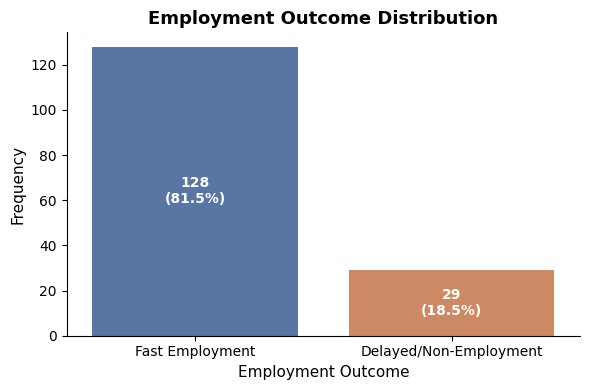

In [541]:
# ---------------------------------
# Employment Outcome Distribution
# ---------------------------------

print("\033[1mEmployment Outcome Frequency\033[0m")
print(df["employment_outcome"].value_counts().to_string())

print()

print("\033[1mEmployment Outcome Percentage\033[0m")
print((df["employment_outcome"].value_counts(normalize=True) * 100).round(2).to_string())

print()


# ---------------------------------
# Visualization
# ---------------------------------

plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x="employment_outcome",
    palette=["#4C72B0", "#DD8452"]   # Blue and Orange
)

# Labels inside the bars
total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percent = 100 * count / total

    ax.annotate(
        f"{count}\n({percent:.1f}%)",
        (
            p.get_x() + p.get_width() / 2,
            p.get_height() / 2
        ),
        ha="center",
        va="center",
        color="white",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Employment Outcome Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Employment Outcome", fontsize=11)
plt.ylabel("Frequency", fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

### Feature Distributions

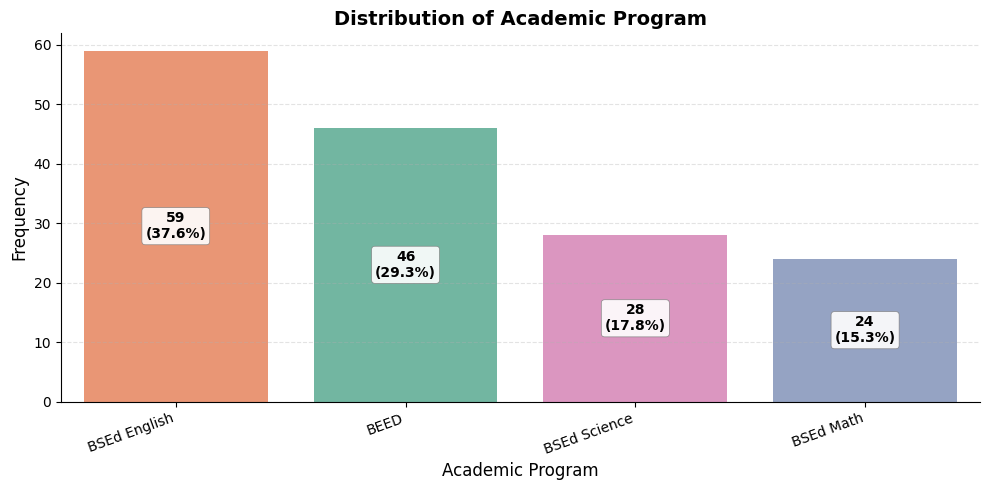

In [542]:
# ---------------------------------
# Nominal Variable
# ---------------------------------

plt.figure(figsize=(10, 5))

order = df["program"].value_counts().index

ax = sns.countplot(
    data=df,
    x="program",
    order=order,
    hue="program",
    palette="Set2",
    legend=False
)

# ---------------------------------
# Frequency Labels
# ---------------------------------

total = len(df)
ylim = ax.get_ylim()[1]

for p in ax.patches:

    count = int(p.get_height())

    if count == 0:
        continue

    percent = count / total * 100

    inside = p.get_height() >= ylim * 0.15

    x = p.get_x() + p.get_width() / 2
    y = p.get_height() / 2 if inside else p.get_height() + ylim * 0.02

    ax.annotate(
        f"{count}\n({percent:.1f}%)",
        (x, y),
        ha="center",
        va="center" if inside else "bottom",
        fontsize=10,
        fontweight="bold",
        color="black",
        bbox=dict(
            facecolor="white",
            edgecolor="gray",
            linewidth=0.5,
            alpha=0.90,
            boxstyle="round,pad=0.25"
        ) if inside else None
    )

# ---------------------------------
# Formatting
# ---------------------------------

plt.title(
    "Distribution of Academic Program",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Academic Program", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.xticks(rotation=20, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.35)

sns.despine()

plt.tight_layout()

plt.show()

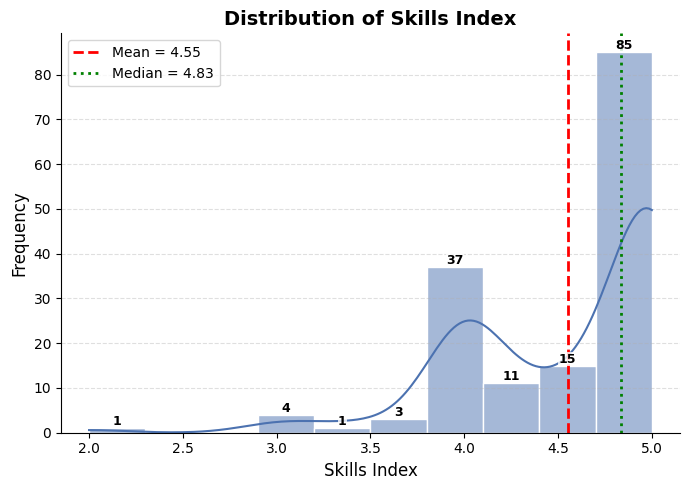

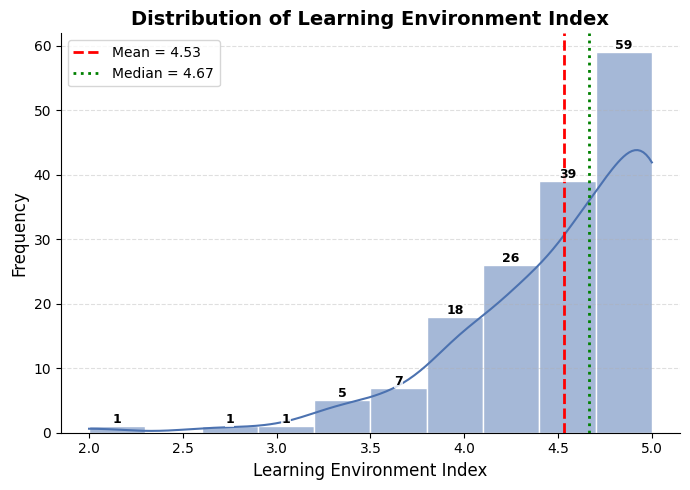

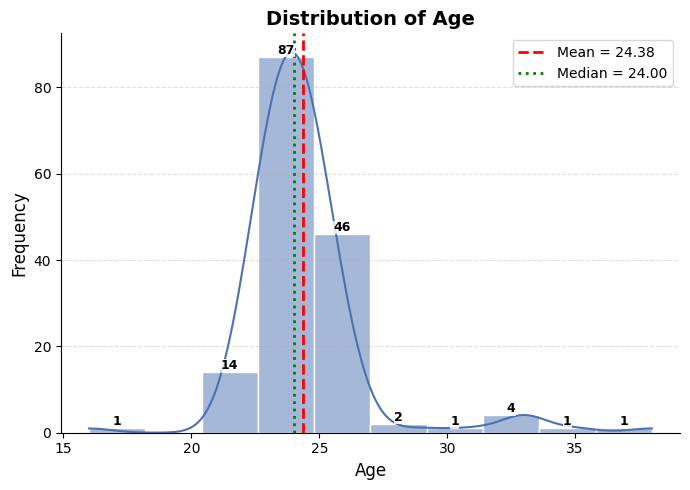

In [543]:
# ---------------------------------
# Numerical Variables
# ---------------------------------

numeric_cols = {

    "skills_index": "Skills Index",
    "learning_environment_index": "Learning Environment Index",
    "age": "Age"

}

for col, title in numeric_cols.items():

    plt.figure(figsize=(7, 5))

    ax = sns.histplot(
        data=df,
        x=col,
        bins=10,
        kde=True,
        color="#4C72B0",
        edgecolor="white",
        linewidth=1
    )
    
    # Mean and Median
    mean = df[col].mean()
    median = df[col].median()

    plt.axvline(mean,
                color="red",
                linestyle="--",
                linewidth=2,
                label=f"Mean = {mean:.2f}")

    plt.axvline(median,
                color="green",
                linestyle=":",
                linewidth=2,
                label=f"Median = {median:.2f}")

    # Frequency labels
    for p in ax.patches:

        if p.get_height() > 0:

            ax.annotate(
                f"{int(p.get_height())}",
                (
                    p.get_x() + p.get_width()/2,
                    p.get_height()
                ),
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.8,
                    pad=0.2
                )
            )

    plt.title(f"Distribution of {title}", fontsize=14, fontweight="bold")
    plt.xlabel(title, fontsize=12)
    plt.ylabel("Frequency", fontsize=12)

    plt.grid(axis="y", linestyle="--", alpha=0.4)

    plt.legend()

    sns.despine()

    plt.tight_layout()

    plt.show()

    print("\n" * 3)

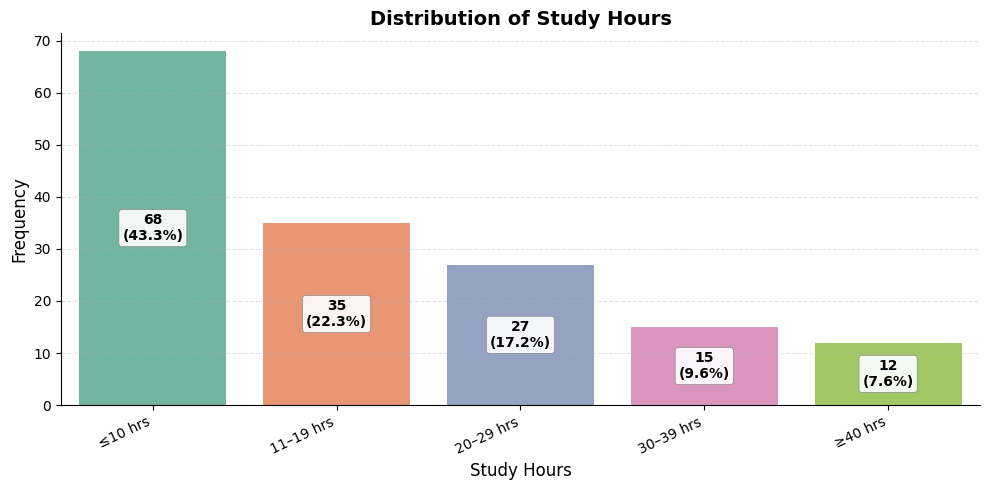

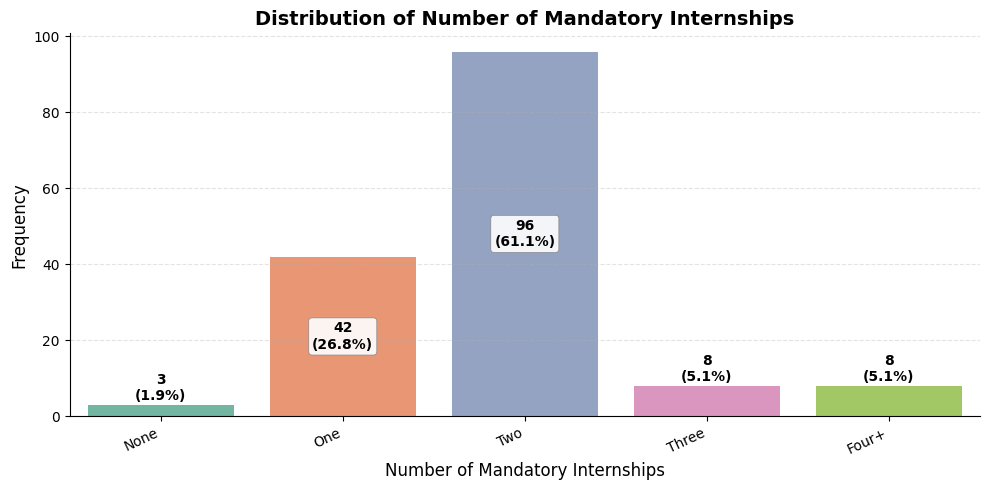

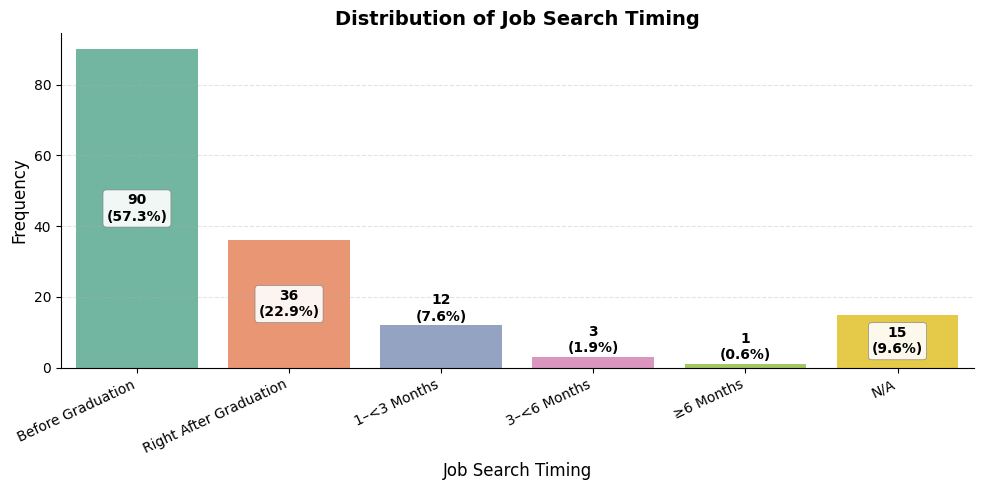

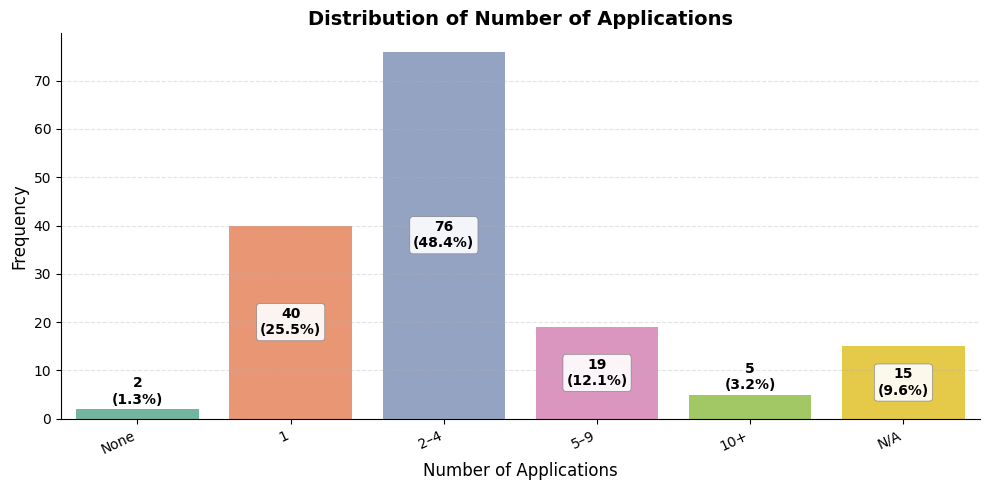

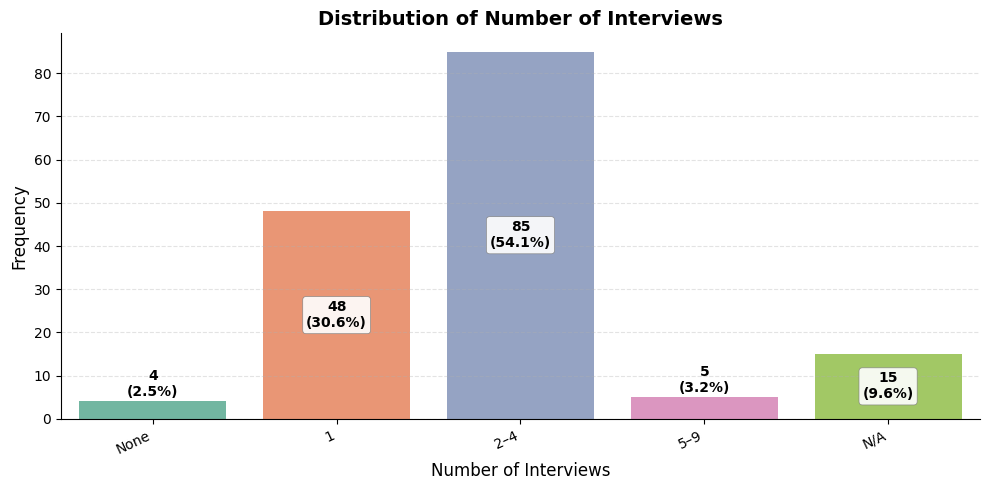

In [544]:
# ---------------------------------
# Ordinal Variables
# ---------------------------------

ordinal_cols = {

    "study_hours": "Study Hours",
    "mandatory_internship_num": "Number of Mandatory Internships",
    "search_timing": "Job Search Timing",
    "num_applications": "Number of Applications",
    "num_interviews": "Number of Interviews"

}

for col, title in ordinal_cols.items():

    order = sorted(df[col].dropna().unique())

    plt.figure(figsize=(10, 5))

    ax = sns.countplot(
        data=df,
        x=col,
        order=order,
        hue=col,
        palette="Set2",
        legend=False
    )

    # ---------------------------------
    # Human-readable x-axis labels
    # ---------------------------------

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(
        [label_maps[col].get(v, str(v)) for v in order],
        rotation=25,
        ha="right"
    )

    # ---------------------------------
    # Frequency Labels
    # ---------------------------------

    total = len(df)
    max_height = max(p.get_height() for p in ax.patches)

    for p in ax.patches:

        count = int(p.get_height())

        if count == 0:
            continue

        percent = count / total * 100

        ylim = ax.get_ylim()[1]
        inside = p.get_height() >= ylim * 0.15

        x = p.get_x() + p.get_width() / 2
        y = p.get_height() / 2 if inside else p.get_height() + 0.5

        ax.annotate(
            f"{count}\n({percent:.1f}%)",
            (x, y),
            ha="center",
            va="center" if inside else "bottom",
            fontsize=10,
            fontweight="bold",
            color="black",
            bbox=dict(
                facecolor="white",
                edgecolor="gray",
                linewidth=0.5,
                alpha=0.9,
                boxstyle="round,pad=0.25"
            ) if inside else None
        )

    # ---------------------------------
    # Formatting
    # ---------------------------------

    plt.title(
        f"Distribution of {title}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(title, fontsize=12)
    plt.ylabel("Frequency", fontsize=12)

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.35
    )

    sns.despine()

    plt.tight_layout()

    plt.show()

    print("\n" * 3)

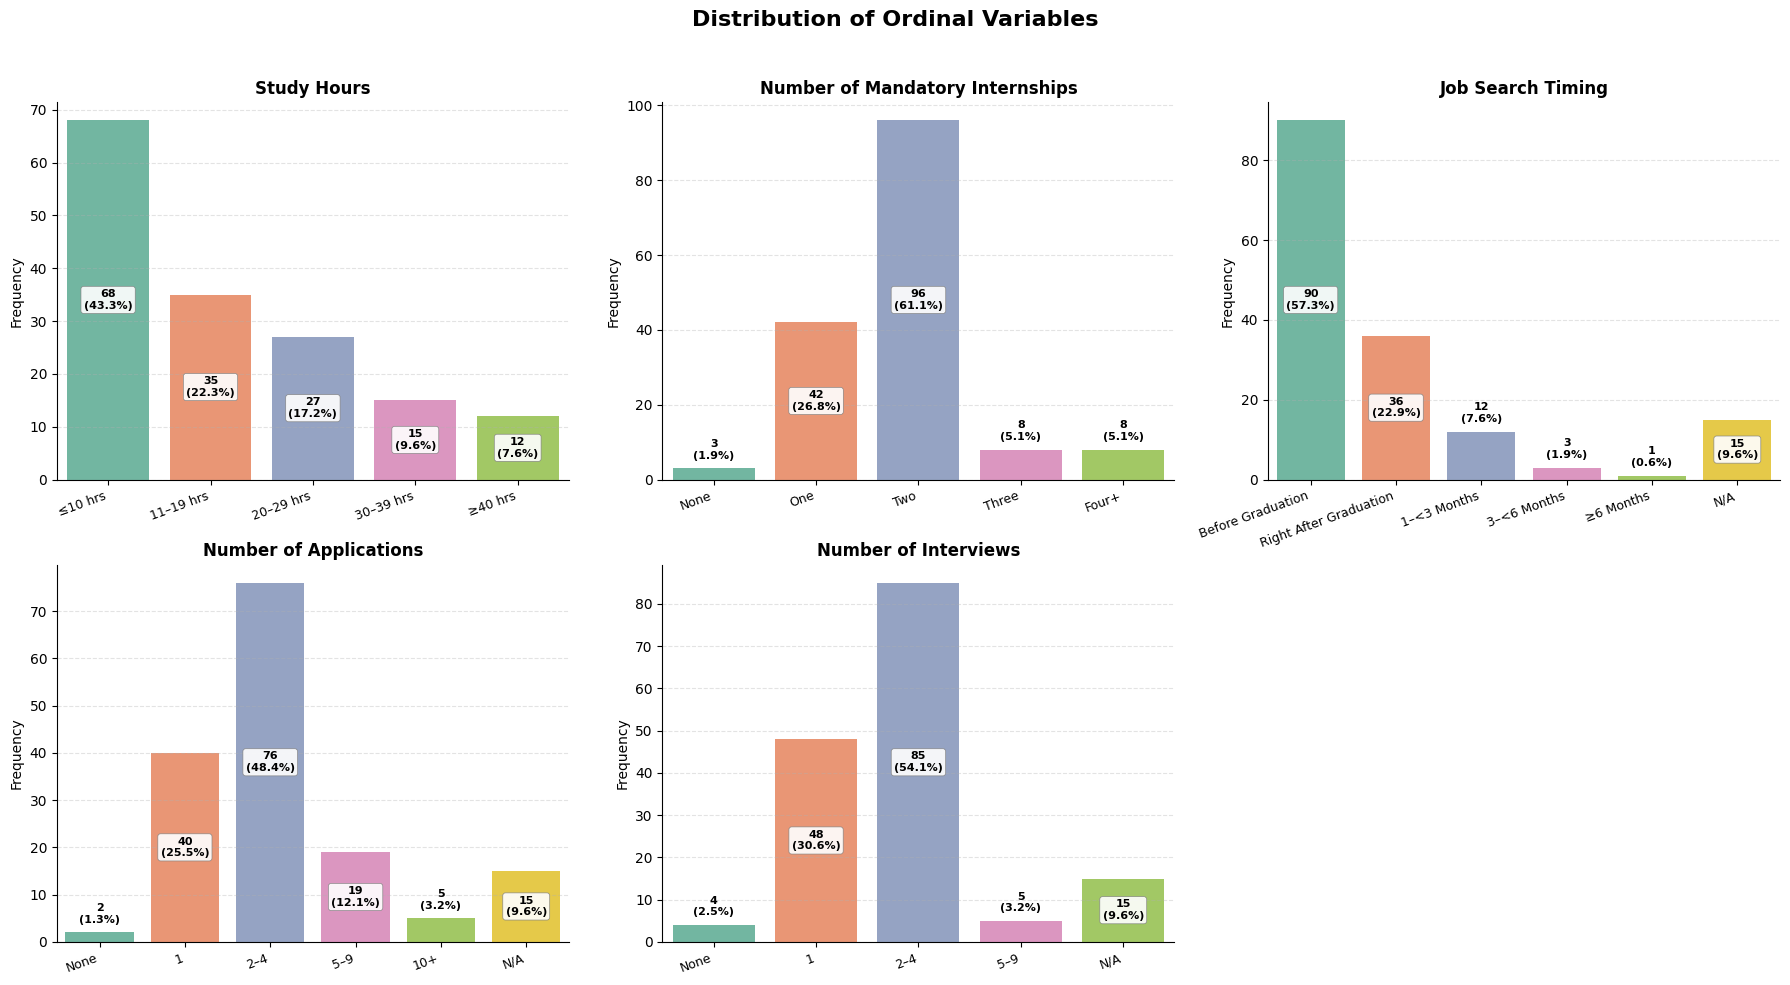

In [545]:
# ---------------------------------
# Ordinal Variables on One Panel
# ---------------------------------

ordinal_cols = {

    "study_hours": "Study Hours",
    "mandatory_internship_num": "Number of Mandatory Internships",
    "search_timing": "Job Search Timing",
    "num_applications": "Number of Applications",
    "num_interviews": "Number of Interviews"

}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (col, title) in zip(axes, ordinal_cols.items()):

    order = sorted(df[col].dropna().unique())

    sns.countplot(
        data=df,
        x=col,
        order=order,
        hue=col,
        palette="Set2",
        legend=False,
        ax=ax
    )

    # ---------------------------------
    # Human-readable x-axis labels
    # ---------------------------------

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(
        [label_maps[col].get(v, str(v)) for v in order],
        rotation=20,
        ha="right",
        fontsize=9
    )

    total = len(df)
    ylim = ax.get_ylim()[1]

    # ---------------------------------
    # Frequency Labels
    # ---------------------------------

    for p in ax.patches:

        count = int(p.get_height())

        if count == 0:
            continue

        percent = count / total * 100

        inside = p.get_height() >= ylim * 0.15

        x = p.get_x() + p.get_width() / 2
        y = p.get_height() / 2 if inside else p.get_height() + ylim * 0.02

        ax.annotate(
            f"{count}\n({percent:.1f}%)",
            (x, y),
            ha="center",
            va="center" if inside else "bottom",
            fontsize=8,
            fontweight="bold",
            color="black",
            bbox=dict(
                facecolor="white",
                edgecolor="gray",
                linewidth=0.5,
                alpha=0.90,
                boxstyle="round,pad=0.25"
            ) if inside else None
        )

    # ---------------------------------
    # Formatting
    # ---------------------------------

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Frequency", fontsize=10)

    ax.grid(axis="y", linestyle="--", alpha=0.35)

    sns.despine(ax=ax)

# Hide unused subplot
axes[-1].axis("off")

plt.suptitle(
    "Distribution of Ordinal Variables",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

print("\n" * 3)

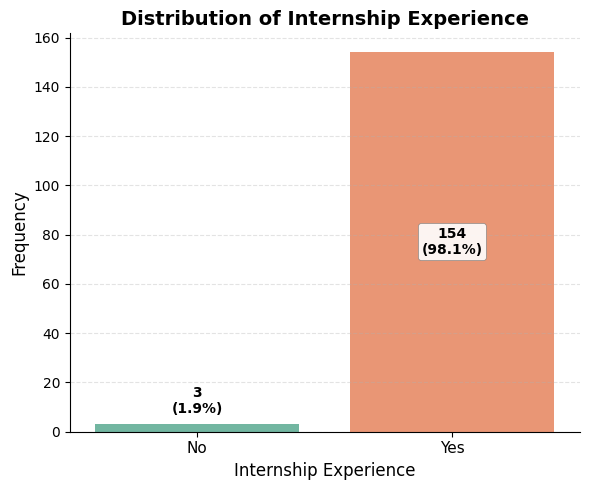

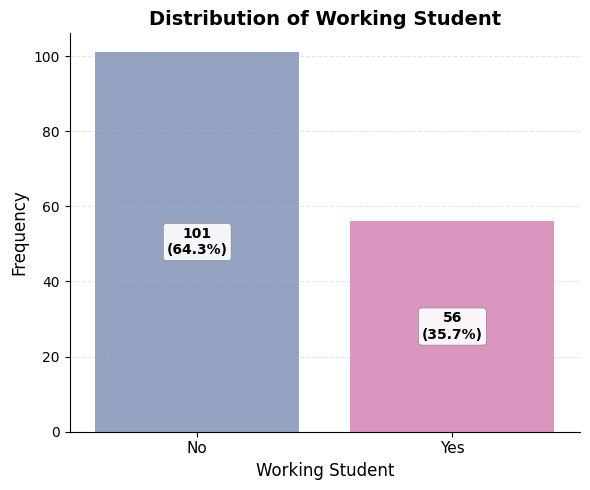

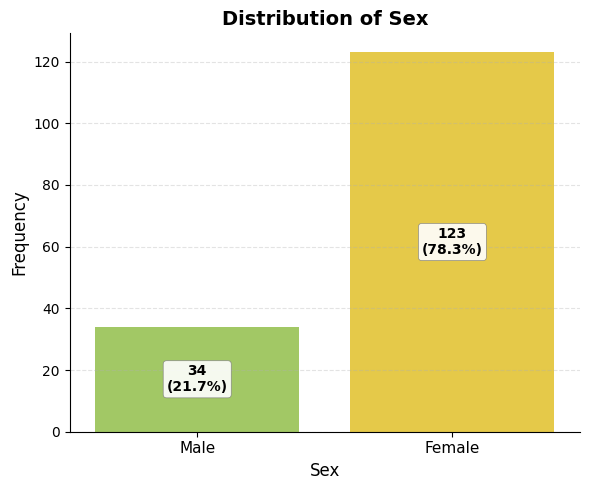

In [546]:
# ---------------------------------
# Binary Variables
# ---------------------------------

binary_cols = {

    "internship": "Internship Experience",
    "working_student": "Working Student",
    "sex": "Sex"

}

# ---------------------------------
# Color Palettes for Binary Variables
# ---------------------------------

binary_palettes = {

    "internship": ["#66C2A5", "#FC8D62"],      # Green / Orange
    "working_student": ["#8DA0CB", "#E78AC3"], # Blue / Pink
    "sex": ["#A6D854", "#FFD92F"]              # Lime / Yellow

}

for col, title in binary_cols.items():

    order = sorted(df[col].dropna().unique())

    plt.figure(figsize=(6, 5))

    ax = sns.countplot(
        data=df,
        x=col,
        order=order,
        hue=col,
        palette=binary_palettes[col],
        legend=False
    )

    # ---------------------------------
    # Human-readable labels
    # ---------------------------------

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(
        [label_maps[col].get(v, str(v)) for v in order],
        fontsize=11
    )

    total = len(df)
    ylim = ax.get_ylim()[1]

    # ---------------------------------
    # Frequency Labels
    # ---------------------------------

    for p in ax.patches:

        count = int(p.get_height())

        if count == 0:
            continue

        percent = count / total * 100

        inside = p.get_height() >= ylim * 0.15

        x = p.get_x() + p.get_width() / 2
        y = p.get_height() / 2 if inside else p.get_height() + ylim * 0.02

        ax.annotate(
            f"{count}\n({percent:.1f}%)",
            (x, y),
            ha="center",
            va="center" if inside else "bottom",
            fontsize=10,
            fontweight="bold",
            color="black",
            bbox=dict(
                facecolor="white",
                edgecolor="gray",
                linewidth=0.5,
                alpha=0.90,
                boxstyle="round,pad=0.25"
            ) if inside else None
        )

    # ---------------------------------
    # Formatting
    # ---------------------------------

    plt.title(
        f"Distribution of {title}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(title, fontsize=12)
    plt.ylabel("Frequency", fontsize=12)

    plt.grid(axis="y", linestyle="--", alpha=0.35)

    sns.despine()

    plt.tight_layout()

    plt.show()

    print("\n" * 3)

### Bivariate Analysis for Categorical Variables

In [547]:
from scipy.stats import chi2_contingency
import pandas as pd
import numpy as np

# ============================================
# Categorical Predictors
# ============================================

categorical_vars = {

    "program": "Program",
    "internship": "Internship Experience",
    "mandatory_internship_num": "Number of Mandatory Internships",
    "working_student": "Working Student",
    "study_hours": "Study Hours",
    "search_timing": "Job Search Timing",
    "num_applications": "Number of Job Applications",
    "num_interviews": "Number of Job Interviews",
    "sex": "Sex"

}

# ============================================
# Chi-square Summary
# ============================================

results = []

for col, label in categorical_vars.items():

    contingency_table = pd.crosstab(
        df[col],
        df["employment_outcome"]
    )

    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # --------------------------------------------
    # Cramer's V
    # --------------------------------------------

    n = contingency_table.to_numpy().sum()

    r, c = contingency_table.shape

    cramers_v = np.sqrt(
        chi2 / (n * (min(r - 1, c - 1)))
    )

    # --------------------------------------------
    # Interpretation
    # --------------------------------------------

    if cramers_v < 0.10:
        interpretation = "Negligible"
    elif cramers_v < 0.30:
        interpretation = "Small"
    elif cramers_v < 0.50:
        interpretation = "Moderate"
    else:
        interpretation = "Large"

    results.append({

        "Predictor Variable": label,
        "Chi-square (χ²)": chi2,
        "Degrees of Freedom": dof,
        "p-value": p,
        "Cramer's V": cramers_v,
        "Association Strength": interpretation,
        "Significant (α = .05)": "Yes" if p < 0.05 else "No"

    })

summary_table = pd.DataFrame(results)

# ============================================
# Sort by p-value
# ============================================

summary_table = summary_table.sort_values(
    by="p-value"
).reset_index(drop=True)

# ============================================
# Display
# ============================================

display(

    summary_table.style

    .hide(axis="index")

    .format({

        "Chi-square (χ²)": "{:.3f}",
        "p-value": "{:.4f}",
        "Cramer's V": "{:.3f}"

    })

    .set_properties(**{

        "text-align": "left"

    })

    .set_table_styles([

        {
            "selector": "th",
            "props": [
                ("text-align", "left"),
                ("font-weight", "bold")
            ]
        },

        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "15px"),
                ("font-weight", "bold")
            ]
        }

    ])

    .set_caption(
        "Table. Summary of Chi-square Tests Between Categorical Predictors and Employment Outcome"
    )

)

Predictor Variable,Chi-square (χ²),Degrees of Freedom,p-value,Cramer's V,Association Strength,Significant (α = .05)
Number of Job Applications,30.720,5,0.0000,0.442,Moderate,Yes
Number of Job Interviews,22.689,4,0.0001,0.380,Moderate,Yes
Job Search Timing,24.746,5,0.0002,0.397,Moderate,Yes
Working Student,4.325,1,0.0376,0.166,Small,Yes
Internship Experience,2.019,1,0.1554,0.113,Small,No
Study Hours,6.546,4,0.1619,0.204,Small,No
Number of Mandatory Internships,6.317,4,0.1767,0.201,Small,No
Program,1.132,3,0.7693,0.085,Negligible,No
Sex,0.000,1,1.0000,0.000,Negligible,No


> A Chi-square test of independence was conducted to determine whether the categorical predictor variables were significantly associated with employment outcome. As shown in the table, four variables demonstrated statistically significant associations with employment outcome at the 0.05 level.

> Among the predictors, **Number of Job Applications** exhibited the strongest association with employment outcome (χ² = 30.720, df = 5, p < .001, Cramér's V = 0.442), indicating a **moderate association**. Similarly, **Job Search Timing** (χ² = 24.746, df = 5, p < .001, Cramér's V = 0.397) and **Number of Job Interviews** (χ² = 22.689, df = 4, p < .001, Cramér's V = 0.380) also demonstrated **moderate associations** with employment outcome. These findings suggest that graduates' job search behavior is closely related to whether they obtained employment quickly or experienced delayed or non-employment.

> **Working Student Experience** was likewise significantly associated with employment outcome (χ² = 4.325, df = 1, p = .038, Cramér's V = 0.166). However, its effect size was classified as **small**, indicating that although the relationship was statistically significant, its practical association with employment outcome was relatively weak.

> In contrast, **Internship Experience** (χ² = 2.019, p = .155), **Study Hours** (χ² = 6.546, p = .162), **Number of Mandatory Internships** (χ² = 6.317, p = .177), **Program** (χ² = 1.132, p = .769), and **Sex** (χ² = 0.000, p = 1.000) were not significantly associated with employment outcome. Furthermore, Program and Sex exhibited negligible effect sizes, whereas Internship Experience, Study Hours, and Number of Mandatory Internships showed only small associations, indicating limited evidence of meaningful relationships with employment outcome within the present dataset.

> Overall, the results suggest that variables related to **job search behavior**—particularly the timing of job search activities, the number of employers approached, and the number of interview invitations received—have stronger associations with employment outcomes than demographic characteristics or academic experiences. These findings provide preliminary evidence that proactive job search activities may play a more important role in achieving faster employment after graduation. Nevertheless, the absence of statistically significant associations for several predictors does not necessarily imply that they lack predictive value in the subsequent machine learning models, as machine learning algorithms evaluate the combined contribution and interactions of multiple variables rather than relying solely on individual statistical associations.


### Crosstabs for Significant Variables

In [548]:
significant_vars = {

    "num_applications": "Number of Job Applications",
    "num_interviews": "Number of Job Interviews",
    "search_timing": "Job Search Timing",
    "working_student": "Working Student"

}

for col, title in significant_vars.items():

    print("=" * 90)
    print(title.upper())
    print("=" * 90)

    # --------------------------------------------
    # Frequency Crosstab
    # --------------------------------------------

    freq = pd.crosstab(
        df[col],
        df["employment_outcome"]
    )

    # --------------------------------------------
    # Row Percentages
    # --------------------------------------------

    percent = pd.crosstab(
        df[col],
        df["employment_outcome"],
        normalize="index"
    ) * 100

    # --------------------------------------------
    # Publication-ready Table
    # --------------------------------------------

    rows = []

    for category in freq.index:

        rows.append({

            "Category": label_maps[col].get(category, category),

            "Fast Employment":
                f"{freq.loc[category, 'Fast Employment']} "
                f"({percent.loc[category, 'Fast Employment']:.1f}%)",

            "Delayed/Non-Employment":
                f"{freq.loc[category, 'Delayed/Non-Employment']} "
                f"({percent.loc[category, 'Delayed/Non-Employment']:.1f}%)"

        })

    table = pd.DataFrame(rows)

    display(

        table.style

        .hide(axis="index")

        .set_properties(**{

            "text-align": "left"

        })

        .set_table_styles([

            {
                "selector": "th",
                "props": [

                    ("text-align", "left"),
                    ("font-weight", "bold")

                ]
            },

            {
                "selector": "caption",
                "props": [

                    ("caption-side", "top"),
                    ("font-size", "14px"),
                    ("font-weight", "bold")

                ]
            }

        ])

        .set_caption(
            f"Table. Employment Outcome by {title}"
        )

    )

    print("\n\n")

NUMBER OF JOB APPLICATIONS


Category,Fast Employment,Delayed/Non-Employment
None,0 (0.0%),2 (100.0%)
1,37 (92.5%),3 (7.5%)
2–4,66 (86.8%),10 (13.2%)
5–9,15 (78.9%),4 (21.1%)
10+,4 (80.0%),1 (20.0%)
N/A,6 (40.0%),9 (60.0%)





NUMBER OF JOB INTERVIEWS


Category,Fast Employment,Delayed/Non-Employment
None,2 (50.0%),2 (50.0%)
1,42 (87.5%),6 (12.5%)
2–4,74 (87.1%),11 (12.9%)
5–9,4 (80.0%),1 (20.0%)
N/A,6 (40.0%),9 (60.0%)





JOB SEARCH TIMING


Category,Fast Employment,Delayed/Non-Employment
Before Graduation,78 (86.7%),12 (13.3%)
Right After Graduation,30 (83.3%),6 (16.7%)
1–<3 Months,11 (91.7%),1 (8.3%)
3–<6 Months,3 (100.0%),0 (0.0%)
≥6 Months,0 (0.0%),1 (100.0%)
N/A,6 (40.0%),9 (60.0%)





WORKING STUDENT


Category,Fast Employment,Delayed/Non-Employment
No,77 (76.2%),24 (23.8%)
Yes,51 (91.1%),5 (8.9%)


### Key Insights

#### Number of Job Applications
- Graduates who submitted **one to four job applications** demonstrated the highest proportions of fast employment (86.8%–92.5%).
- Respondents who **did not apply for jobs** or were classified as **Not Applicable** exhibited higher rates of delayed or non-employment.

#### Number of Job Interviews
- Graduates who received **at least one interview invitation** consistently showed high rates of fast employment (80.0%–87.5%).
- Those with **no interview invitations** or classified as **Not Applicable** experienced higher rates of delayed or non-employment.

#### Job Search Timing
- Graduates who **began searching for jobs before or shortly after graduation** generally exhibited high proportions of fast employment (83.3%–91.7%).
- Delaying the job search until **six months or more after graduation** was associated with delayed or non-employment.

#### Working-Student Experience
- **Working students** had a higher proportion of fast employment (91.1%) than non-working students (76.2%).
- Delayed or non-employment was more common among graduates without working-student experience.

> **Note:** Categories with very small sample sizes (e.g., **None**, **≥6 Months**, and **10+**) should be interpreted with caution, as their percentages may not be representative.

### Normality Assessment for Numerical Variables

In [549]:
from scipy.stats import shapiro
import pandas as pd

# ============================================
# Normality Assessment
# ============================================

numeric_vars = {

    "age": "Age",
    "skills_index": "Skills Index",
    "learning_environment_index": "Learning Environment Index"

}

normality_results = []

for col, title in numeric_vars.items():

    fast = df.loc[
        df["employment_outcome"] == "Fast Employment",
        col
    ].dropna()

    delayed = df.loc[
        df["employment_outcome"] == "Delayed/Non-Employment",
        col
    ].dropna()

    stat_fast, p_fast = shapiro(fast)
    stat_delayed, p_delayed = shapiro(delayed)

    normal = (p_fast > 0.05) and (p_delayed > 0.05)

    normality_results.append({

        "Variable": title,
        "Fast Employment W": round(stat_fast, 3),
        "Fast Employment p": round(p_fast, 4),
        "Delayed Employment W": round(stat_delayed, 3),
        "Delayed Employment p": round(p_delayed, 4),
        "Normally Distributed?": "Yes" if normal else "No",
        "Statistical Test Selected":
            "Independent t-test" if normal else "Mann–Whitney U"

    })

normality_table = pd.DataFrame(normality_results)

display(

    normality_table.style

    .hide(axis="index")

    .format({

        "Fast Employment W": "{:.3f}",
        "Delayed Employment W": "{:.3f}",
        "Fast Employment p": "{:.4f}",
        "Delayed Employment p": "{:.4f}"

    })

    .set_caption(
        "Table. Shapiro–Wilk Normality Test and Selection of Statistical Test"
    )

)

Variable,Fast Employment W,Fast Employment p,Delayed Employment W,Delayed Employment p,Normally Distributed?,Statistical Test Selected
Age,0.682,0.0000,0.720,0.0000,No,Mann–Whitney U
Skills Index,0.754,0.0000,0.840,0.0005,No,Mann–Whitney U
Learning Environment Index,0.806,0.0000,0.832,0.0003,No,Mann–Whitney U


> Normality was assessed using the Shapiro–Wilk test. Since at least one comparison group violated the normality assumption for each numerical variable, the Mann–Whitney U test was used.


###  Bivariate Analysis of Numerical Predictors by Employment Outcome

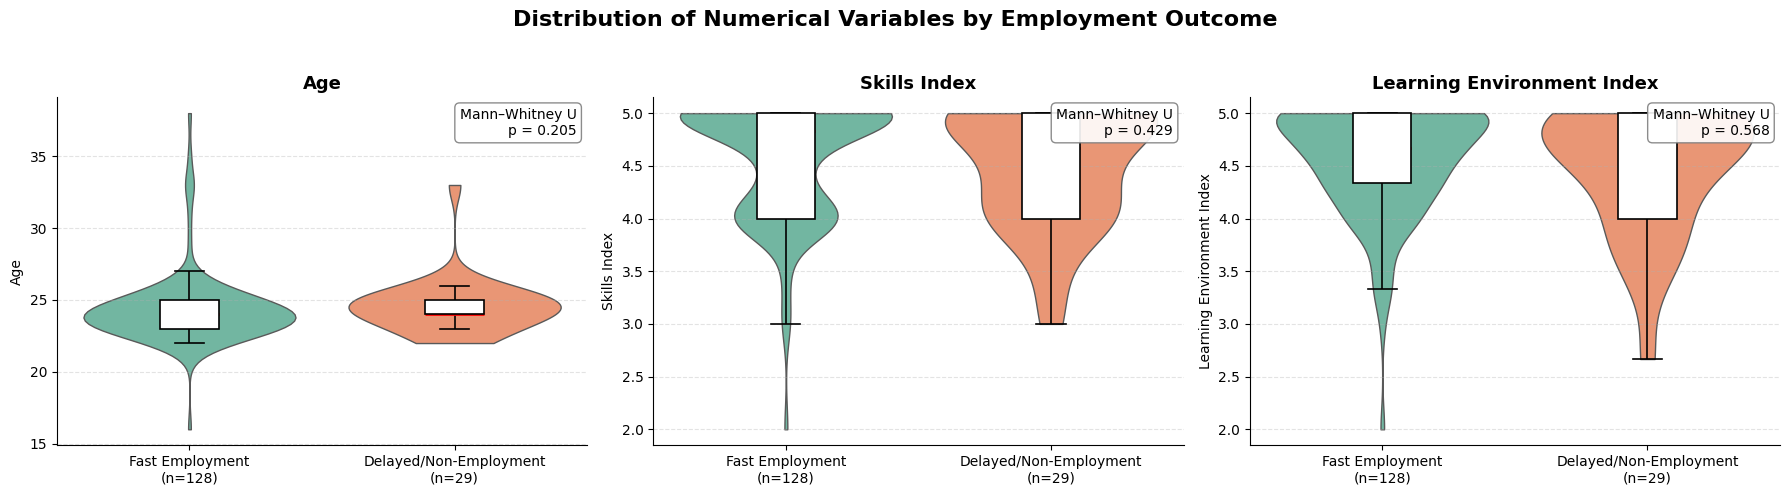

Variable,Test,Statistic,p-value,Significant (α=.05)
Age,Mann–Whitney U,1583.500,0.2054,No
Skills Index,Mann–Whitney U,2020.500,0.4289,No
Learning Environment Index,Mann–Whitney U,1978.000,0.5678,No


In [550]:
from scipy.stats import mannwhitneyu
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# Numerical Variables
# ============================================

numeric_vars = {

    "age": "Age",
    "skills_index": "Skills Index",
    "learning_environment_index": "Learning Environment Index"

}

results = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, title) in zip(axes, numeric_vars.items()):

    # ---------------------------------
    # Separate Groups
    # ---------------------------------

    fast = df.loc[
        df["employment_outcome"] == "Fast Employment",
        col
    ].dropna()

    delayed = df.loc[
        df["employment_outcome"] == "Delayed/Non-Employment",
        col
    ].dropna()

    fast_n = len(fast)
    delayed_n = len(delayed)

    # ---------------------------------
    # Mann–Whitney U Test
    # ---------------------------------
    # Based on the separate Shapiro–Wilk normality assessment,
    # the normality assumption was violated for these variables.
    
    stat, p = mannwhitneyu(
        fast,
        delayed,
        alternative="two-sided"
    )
    
    test = "Mann–Whitney U"

    # ---------------------------------
    # Save Results
    # ---------------------------------

    results.append({

        "Variable": title,
        "Test": test,
        "Statistic": round(stat, 3),
        "p-value": round(p, 4),
        "Significant (α=.05)": "Yes" if p < 0.05 else "No"

    })

    # ============================================
    # Violin Plot
    # ============================================

    sns.violinplot(
        data=df,
        x="employment_outcome",
        y=col,
        hue="employment_outcome",
        palette="Set2",
        inner=None,
        cut=0,
        linewidth=1,
        legend=False,
        ax=ax
    )

    # ============================================
    # Overlay Narrow Boxplot
    # ============================================

    sns.boxplot(
        data=df,
        x="employment_outcome",
        y=col,
        width=0.22,
        showcaps=True,
        showfliers=False,
        boxprops={
            "facecolor": "white",
            "edgecolor": "black",
            "linewidth": 1.2,
            "zorder": 3
        },
        whiskerprops={
            "linewidth": 1.2,
            "color": "black"
        },
        capprops={
            "linewidth": 1.2,
            "color": "black"
        },
        medianprops={
            "linewidth": 2,
            "color": "red"
        },
        ax=ax
    )

    # ============================================
    # Sample Size
    # ============================================

    ax.set_xticklabels([

        f"Fast Employment\n(n={fast_n})",
        f"Delayed/Non-Employment\n(n={delayed_n})"

    ])

    # ============================================
    # Statistical Test Annotation
    # ============================================

    if p < 0.001:
        p_text = "p < .001"
    else:
        p_text = f"p = {p:.3f}"

    ax.text(
        0.98,
        0.97,
        f"{test}\n{p_text}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(
            facecolor="white",
            edgecolor="gray",
            alpha=0.90,
            boxstyle="round,pad=0.35"
        )
    )

    # ============================================
    # Formatting
    # ============================================

    ax.set_title(
        title,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel("")
    ax.set_ylabel(title)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.35
    )

    sns.despine(ax=ax)

# ============================================
# Overall Figure
# ============================================

plt.suptitle(
    "Distribution of Numerical Variables by Employment Outcome",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

print("\n\n")

# ============================================
# Statistical Summary Table
# ============================================

results = pd.DataFrame(results)

display(

    results.style

    .hide(axis="index")

    .format({

        "Statistic": "{:.3f}",
        "p-value": "{:.4f}"

    })

    .set_properties(**{

        "text-align": "left"

    })

    .set_table_styles([

        {
            "selector": "th",
            "props": [
                ("text-align", "left"),
                ("font-weight", "bold")
            ]
        },

        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "15px"),
                ("font-weight", "bold")
            ]
        }

    ])

    .set_caption(
        "Table. Comparison of Numerical Variables by Employment Outcome"
    )

)

### Correlation Matrix/ Pearson Correlation Heatmap

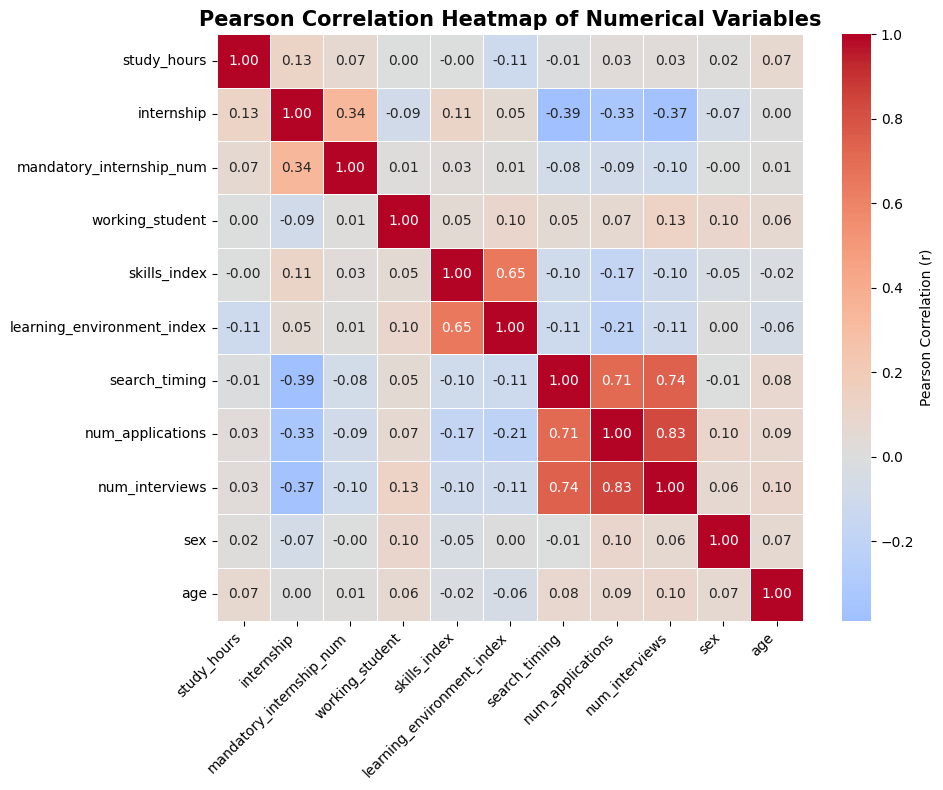

In [554]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# Pearson Correlation Matrix
# ============================================

corr = df.select_dtypes(include=np.number).corr(method="pearson")

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation (r)"}
)

plt.title(
    "Pearson Correlation Heatmap of Numerical Variables",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

### Detect Class Imbalance

In [552]:
class_counts = df["employment_outcome"].value_counts()

print(class_counts)

print()

print(class_counts / len(df) * 100)

employment_outcome
Fast Employment           128
Delayed/Non-Employment     29
Name: count, dtype: int64

employment_outcome
Fast Employment           81.528662
Delayed/Non-Employment    18.471338
Name: count, dtype: float64


### Feature Importance (Exploratory)

Predictor,Importance
num_applications,0.1107
age,0.1095
Program,0.1072
search_timing,0.1069
skills_index,0.1025
num_interviews,0.1025
learning_environment_index,0.0950
study_hours,0.0815
working_student,0.0710
mandatory_internship_num,0.0643


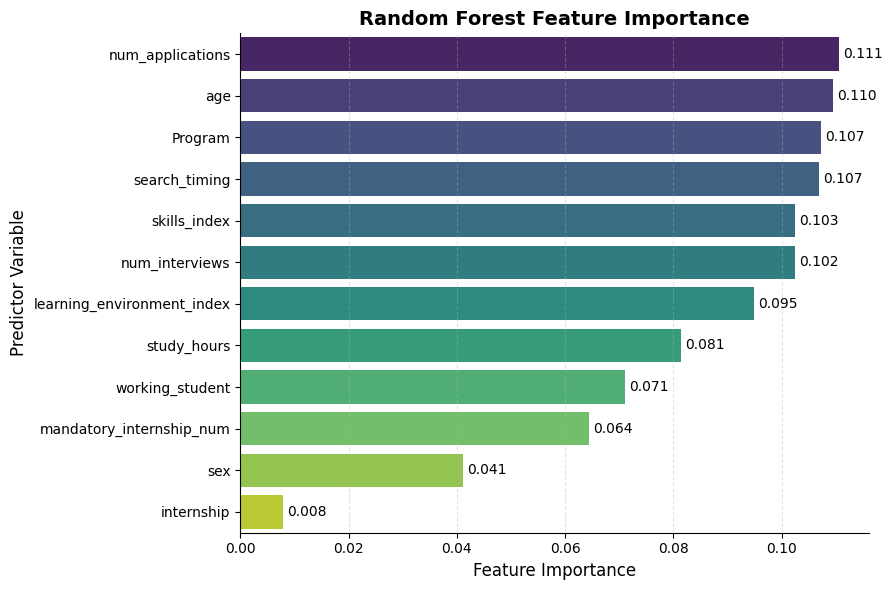

In [553]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# Encode Target Variable
# ============================================

le = LabelEncoder()

y = le.fit_transform(df["employment_outcome"])

# ============================================
# One-Hot Encode Predictors
# Keep all program categories
# ============================================

X = pd.get_dummies(
    df.drop(columns=["employment_outcome"]),
    drop_first=False
)

# ============================================
# Train Random Forest
# ============================================

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

rf.fit(X, y)

# ============================================
# Extract Feature Importances
# ============================================

importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": rf.feature_importances_

})

# ============================================
# Combine Dummy Variables Back to Original Predictors
# ============================================

importance["Predictor"] = importance["Feature"]

# Combine all Program dummy variables
importance.loc[
    importance["Feature"].str.startswith("program_"),
    "Predictor"
] = "Program"

# (Optional) If you later dummy encode other nominal variables,
# you can combine them similarly.

# ============================================
# Aggregate Importances
# ============================================

importance = (
    importance
    .groupby("Predictor", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
)

# ============================================
# Display Table
# ============================================

display(
    importance.style
    .hide(axis="index")
    .format({"Importance": "{:.4f}"})
    .set_caption("Table. Aggregated Random Forest Feature Importance")
)

# ============================================
# Plot
# ============================================

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=importance,
    x="Importance",
    y="Predictor",
    hue="Predictor",
    palette="viridis",
    legend=False
)

# Value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=10
    )

plt.title(
    "Random Forest Feature Importance",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Feature Importance", fontsize=12)
plt.ylabel("Predictor Variable", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.35)

sns.despine()

plt.tight_layout()

plt.show()